## EJERCICIO 18 + 19

In [ ]:
df_regresion = df_datos[(df_datos['ESTADO_1'] == True) & (df_datos['P47T'] > 0)]
df_regresion['P47T'] = np.log(df_regresion['P47T'])

## EJERCICIO 20 + 21

In [ ]:
from sklearn.model_selection import train_test_split

columnas_no_continuas = columnas_a_convertir_a_dummy + ['SECTOR']
columnas_continuas = df_regresion.columns.difference(columnas_no_continuas).drop('P47T')

X = df_regresion.drop(columns=['P47T'])
y = df_regresion['P47T']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columnas_continuas] = scaler.fit_transform(X_train[columnas_continuas])
X_test_scaled[columnas_continuas] = scaler.transform(X_test[columnas_continuas])

# Separamos train-test y solo escalamos las variables numéricas continuas (chequear si está bien eso ja)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


regresion_lineal_ordinaria = LinearRegression()
regresion_lineal_ordinaria.fit(X_train_scaled, y_train)

y_pred_regresion_lineal_ordinaria = regresion_lineal_ordinaria.predict(X_test_scaled)

r2_regresion_lineal_ordinaria = r2_score(y_test, y_pred_regresion_lineal_ordinaria)
mse_regresion_lineal_ordinaria = mean_squared_error(y_test, y_pred_regresion_lineal_ordinaria)

print(f"R2 de Regresión Lineal Ordinaria: {r2_regresion_lineal_ordinaria}")
print(f"MSE de Regresión Lineal Ordinaria: {mse_regresion_lineal_ordinaria}")

#R2 de Regresión Lineal Ordinaria: 0.4533678713773076
#MSE de Regresión Lineal Ordinaria: 0.3761173986172217

In [ ]:
from sklearn.linear_model import RidgeCV


alphas_de_testeo = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

regresion_ridge = RidgeCV(alphas=alphas_de_testeo, cv=5)
regresion_ridge.fit(X_train_scaled, y_train)
# El alpha óptimo está guardado internamente, ¿deberíamos printearlo?

y_pred_ridge = regresion_ridge.predict(X_test_scaled)

r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"R2 de Regresión Ridge: {r2_ridge}")
print(f"MSE de Regresión Ridge: {mse_ridge}")

#R2 de Regresión Ridge: 0.4539135721216544
#MSE de Regresión Ridge: 0.3757419220697594

## Redes Neuronales

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


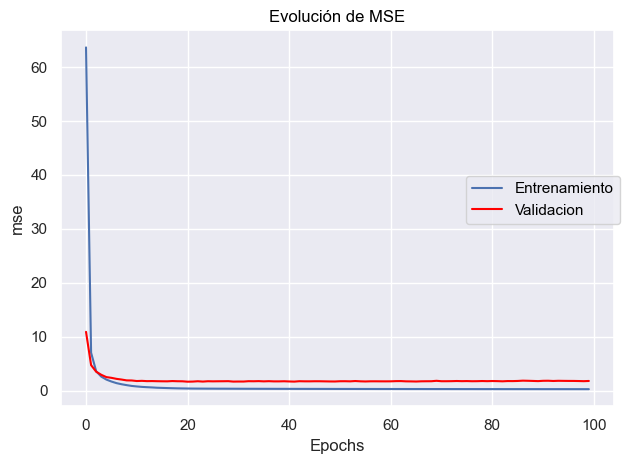

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4950 - mse: 0.4950
MSE de Red Neuronal: 0.5040653944015503


In [ ]:
redes_neuronales = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

optimizador = tf.keras.optimizers.SGD(learning_rate=0.01, clipnorm=1.0) #Chequear validez de uso de clipnorm
#Justificar elección de hiperparámetros en este modelo, ¿cómo? (learning_rate, ¿activación?, ¿n de capas ocultas?, ¿batch_size?)
redes_neuronales.compile(optimizer=optimizador, loss='mse', metrics=['mse'])

history = redes_neuronales.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

def graficar_error(history, error_name):
    x_arr = np.array(history.epoch) 
    
    plot = (
        so.Plot()
        .add(so.Line(), x=x_arr, y=history.history[error_name], label='Entrenamiento')
        .add(so.Line(color = "red"), x=x_arr, y=history.history[f'val_{error_name}'], label='Validacion')
        .label(title=f"Evolución de {error_name.upper()}", x="Epochs", y=error_name)
    )
    return plot


grafico_mse = graficar_error(history, 'mse')
grafico_mse.show()

funcion_de_perdida = redes_neuronales.evaluate(X_test_scaled, y_test)[0]

print(f"MSE de Red Neuronal: {funcion_de_perdida}")

## ¿R2 como métrica de la red neuronal? Creo que no es nativo